Analyze results from the pathway enrichment across all conditions and -omes

## Setup

### Imports

In [1]:
import os
from typing import Optional, Literal

import polars as pl
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt, rcParams, colors, cm

# set max font size 
rcParams["font.size"] = 7

### Constants

In [ ]:
# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "pathway_enrichment"
)

# directory for differentially expressed features
RESULTS_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "pathway_enrichment"
)

### Load Data

#### Helper Function: load all pathway enrichment results from specified comparison

In [3]:
def load_pathway_results(
    subset_id: str,
    direction: str
) -> Optional[pl.DataFrame] :
    # gather all of the results from the different databases and
    # sources of differentially expressed proteins
    all_results = [
        (
            pl.read_csv(results_f)
            .with_columns(
                (
                    pl.lit(block)
                    .alias("block")
                ),
                (
                    pl.concat_str(
                        pl.lit(f"[{db[0].upper()}]"),
                        pl.col("pathway_name"),
                        separator=" "
                    )
                    .alias("pathway_name")
                )
            )
            .select(
                "pathway_name",
                "block",
                "gene_count",
                "p_adjust",
                "gene_symbols",
                "pathway_genes"
            )
            .sort("p_adjust")
            .head(5)
        )
        for db in ["hallmark", "kegg", "reactome"]
        for block in ["Transcriptomics", "Proteomics", "Lipid-Protein-Associations"]
        if os.path.isfile(results_f := os.path.join(   
                RESULTS_DIR,
                f"{db}/{subset_id}_{block}_{direction}.csv"
        ))
    ]
    if all_results:
        # filter the resulting pathways to remove any duplicate entries
        return (
            pl.concat(all_results)
            .sort(
                "p_adjust",
            )
            .group_by(
                "pathway_name",
                "block",
            )
            .agg(
                pl.col("gene_count").first(),
                pl.col("p_adjust").first(),
                pl.col("gene_symbols").first(),
                pl.col("pathway_genes").first()
            )
            .with_row_index()
        )
    # if no results, return None
    return None

#### Pre-load all of the pathway enrichment results

In [4]:
# key: (subset_id, direction)
# value: pathway_results_dataframe
results = {
    (subset_id, direction): r 
    for subset_id in [
        "B_NPM1-WT", "W_NPM1-WT", 
        "B_FLT3-ITD-WT", "W_FLT3-ITD-WT", 
        "B_FLT3-ITDxNPM1-WT", "W_FLT3-ITDxNPM1-WT"
    ]
    for direction in ["up", "down"]
    if (r := load_pathway_results(subset_id, direction)) is not None
}

## Analysis
### Helper Functions

In [5]:
def v2c(
    v: float, 
    vmin: float, 
    vmax: float
) -> str : 
    """
    map a value to a color using the "coolwarm" colormap
    """
    return colors.to_hex(
        cm.ScalarMappable(
            norm=colors.Normalize(vmin=vmin, vmax=vmax), 
            cmap="coolwarm"
        ).to_rgba(v)  # type: ignore
    )

In [6]:
v2c(5, -10, 10)

'#f4987a'

In [7]:
"#f4987a"

'#f4987a'

In [8]:
results.keys()

dict_keys([('B_NPM1-WT', 'up'), ('B_NPM1-WT', 'down'), ('W_NPM1-WT', 'up'), ('W_NPM1-WT', 'down'), ('B_FLT3-ITD-WT', 'up'), ('B_FLT3-ITD-WT', 'down'), ('W_FLT3-ITD-WT', 'up'), ('W_FLT3-ITD-WT', 'down'), ('B_FLT3-ITDxNPM1-WT', 'up'), ('B_FLT3-ITDxNPM1-WT', 'down'), ('W_FLT3-ITDxNPM1-WT', 'up'), ('W_FLT3-ITDxNPM1-WT', 'down')])

In [9]:
r = results[("B_NPM1-WT", "down")]
r

index,pathway_name,block,gene_count,p_adjust,gene_symbols,pathway_genes
u32,str,str,i64,f64,str,str
0,"""[K] Arachidonic acid metabolis…","""Proteomics""",5,0.043262,"""HPGDS/ALOX12/HPGD/PLA2G2A/ALOX…","""AKR1C3/AKR1C8/ALOX12/ALOX12B/A…"
1,"""[K] Hematopoietic cell lineage""","""Transcriptomics""",9,0.000124,"""CD34/HLA-DPB1/HLA-DMB/HLA-DPA1…","""ANPEP/CD14/CD19/CD1A/CD1B/CD1C…"
2,"""[R] Neutrophil degranulation""","""Proteomics""",16,0.044063,"""CD177/CHI3L1/PRG3/CKAP4/SLC44A…","""A1BG/ABCA13/ACAA1/ACLY/ACP3/AC…"
3,"""[R] Translocation of ZAP-70 to…","""Transcriptomics""",4,0.036252,"""HLA-DPB1/HLA-DPA1/HLA-DRB5/HLA…","""CD247/CD3D/CD3E/CD3G/CD4/HLA-D…"
4,"""[R] Phosphorylation of CD3 and…","""Transcriptomics""",4,0.036252,"""HLA-DPB1/HLA-DPA1/HLA-DRB5/HLA…","""CD247/CD3D/CD3E/CD3G/CD4/CSK/H…"
…,…,…,…,…,…,…
15,"""[K] Cell adhesion molecule (CA…","""Transcriptomics""",11,0.000124,"""CD34/HLA-DPB1/HLA-DMB/HLA-DPA1…","""ALCAM/CADM1/CADM3/CD2/CD22/CD2…"
16,"""[K] Allograft rejection""","""Transcriptomics""",6,0.000206,"""HLA-DPB1/HLA-DMB/HLA-DPA1/HLA-…","""CD28/CD40/CD40LG/CD80/CD86/FAS…"
17,"""[R] G beta:gamma signalling th…","""Transcriptomics""",4,0.040659,"""GNG2/AKT3/GNG7/GNG11""","""AKT1/AKT2/AKT3/GNB1/GNB2/GNB3/…"


In [10]:
def overlap_factor(genes_a, genes_b):
    sa = set(genes_a.split("/"))
    sb = set(genes_b.split("/"))
    return len(sa & sb) / len(sa | sb)

In [11]:
def build_pathway_graph(
    r,
    min_node_size=5,
    min_overlap_factor=0.05,
    top_n_pathways=10
):
    # initialize graph
    g = nx.Graph()

    # add nodes (pathways, metrics as metadata)
    for i, p, b, n, pv in (
        r
        .select(pl.exclude("gene_symbols", "pathway_genes"))
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .iter_rows()    
    ):
        g.add_node(
            i,
            name=p,
            block=b,
            n=n,
            p_value=pv
        )

    # add edges
    for i, pg_i in (
        r
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .select("index", "pathway_genes")
        .iter_rows()    
    ):
        for j, pg_j in (
            r
            .filter(pl.col("gene_count") >= min_node_size)
            .sort("p_adjust")
            .head(top_n_pathways)
            .select("index", "pathway_genes")
            .iter_rows()    
        ):
            if (
                i != j 
                # only add edges for nodes with at least 10% overlap
                and (overlap := overlap_factor(pg_i, pg_j)) > min_overlap_factor
            ): 
                g.add_edge(
                    i,
                    j,
                    overlap=overlap
                )
    
    return g

In [12]:
def plot_pathway_network(
    g, 
    ax,
    direction: Literal["up", "down"],
    add_labels=True,
    label_rotation=10,
) :

    pos = nx.kamada_kawai_layout(g)

    nx.draw_networkx_edges(
        g, 
        pos, 
        ax=ax, 
        edge_color="#999999",
        width=[
            d["overlap"] * 5
            for *_, d in g.edges(data=True)
        ]
    )

    cmult = 1. if direction == "down" else -1.
    szmult = 2

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Transcriptomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_shape="^"
    )

    nx.draw_networkx_nodes(
        g, 
        pos, 
        ax=ax, 
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Proteomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_shape="s"
    )

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Lipid-Protein-Associations"],
        node_color=[
            # take the first omics_type="Lipid-Protein-Associations" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_shape="o"
    )

    if add_labels:
        lbls = nx.draw_networkx_labels(
            g, 
            pos,
            {
                n: d["name"]
                for n, d in g.nodes(data=True)
            }, 
            ax=ax,
            font_size=7,
            font_family="Arial",
            horizontalalignment="left",
            verticalalignment="bottom", 
            clip_on=False
        )
        for _, text in lbls.items():
            text.set_verticalalignment("center")
            text.set_rotation_mode("anchor")
            text.set_rotation(label_rotation)

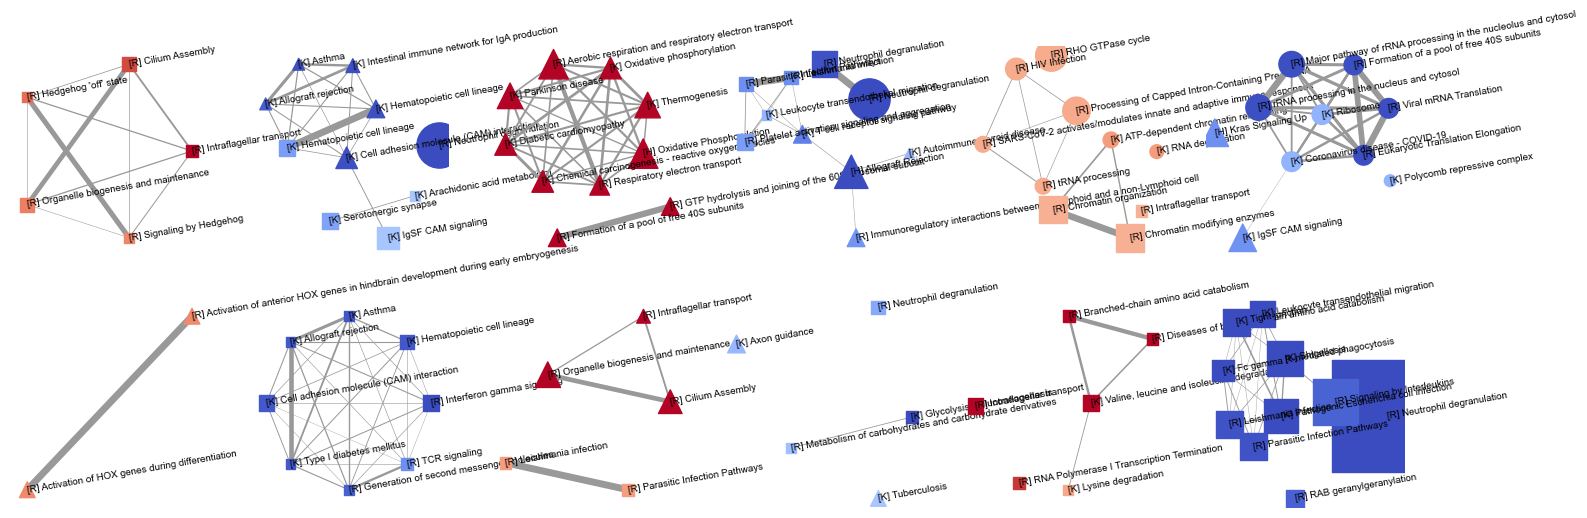

In [13]:
fig, (axs_top, axs_bot) = plt.subplots(
    figsize=(18, 6),
    nrows=2,
    ncols=6
)    

for ax, (subset_id, direction) in zip(axs_top, [(f"B_{m}-WT", d) for m in ["NPM1", "FLT3-ITD", "FLT3-ITDxNPM1"] for d in ["up", "down"]]):
    if (r := results.get((subset_id, direction))) is not None:
        g = build_pathway_graph(r)
        plot_pathway_network(g, ax, direction, add_labels=True)
    ax.set_axis_off()

for ax, (subset_id, direction) in zip(axs_bot, [(f"W_{m}-WT", d) for m in ["NPM1", "FLT3-ITD", "FLT3-ITDxNPM1"] for d in ["up", "down"]]):
    if (r := results.get((subset_id, direction))) is not None:
        g = build_pathway_graph(r)
        plot_pathway_network(g, ax, direction, add_labels=True)
    ax.set_axis_off()

plt.savefig("/Users/dylan.ross/Downloads/out.png", dpi=350, transparent=True)
plt.show()
plt.close()

In [ ]:
r

index,pathway_name,block,gene_count,p_adjust,gene_symbols,pathway_genes
u32,str,str,i64,f64,str,str
0,"""[K] Tight junction""","""Proteomics""",14,0.000007,"""ACTN1/MYH11/ACTG1/TUBA4A/EZR/A…","""ACTB/ACTG1/ACTN1/ACTN4/ACTR2/A…"
1,"""[K] Glutamatergic synapse""","""Transcriptomics""",7,0.04167,"""GNG2/GNG7/GRIN2C/HOMER2/CACNA1…","""ADCY1/ADCY2/ADCY3/ADCY4/ADCY5/…"
2,"""[R] Signaling by Interleukins""","""Proteomics""",23,0.000264,"""ALOX15/CNN2/LCN2/INPP5D/APP/BC…","""ADRM1/AGER/AIP/AKT1/ALOX15/ALO…"
3,"""[R] Leishmania infection""","""Proteomics""",14,0.000138,"""GNG2/GNAI1/PLCG1/APP/GNAZ/GNG1…","""ABI1/ABI2/ABL1/ACTB/ACTG1/ACTR…"
4,"""[R] Regulation of Insulin-like…","""Transcriptomics""",8,0.016211,"""LAMC1/IGFBP7/APP/MGAT4A/P4HB/F…","""ADAM10/AFP/AHSG/ALB/AMBN/AMELX…"
…,…,…,…,…,…,…
12,"""[K] Pathogenic Escherichia col…","""Proteomics""",17,9.6317e-7,"""MYO1H/ARF1/FOS/MYH11/ACTG1/TUB…","""ABCF2/ABCF2-H2BK1/ABI1/ABL1/AC…"
13,"""[R] Parasitic Infection Pathwa…","""Proteomics""",14,0.000138,"""GNG2/GNAI1/PLCG1/APP/GNAZ/GNG1…","""ABI1/ABI2/ABL1/ACTB/ACTG1/ACTR…"
14,"""[K] Shigellosis""","""Proteomics""",18,0.000002,"""PLCG1/ARF1/ACTN1/CCL5/ACTG1/VC…","""ACTB/ACTG1/ACTN1/ACTN4/ACTR2/A…"


In [15]:
r.filter(
    (pl.col("pathway_name").str.starts_with("[R] "))
    & (pl.col("block") == "Lipid-Protein-Associations")    
    & (pl.col("gene_count") >= 5)
)

index,pathway_name,block,gene_count,p_adjust,gene_symbols,pathway_genes
u32,str,str,i64,f64,str,str
